# Cohort Investigation

## What this notebook produces

This notebook builds the population-description pieces the TRIPOD-AI reporting checklist asks for. 

| TRIPOD-AI item | What the guideline is asking for | What this notebook builds for it |
| --- | --- | --- |
| **20a** | How many patients you started with and how many survived each filter, plus a follow-up summary | The attrition table: patient count dropped at every stage |
| **5b** | The calendar span of the data — when the first and last patients entered, and how long they're watched afterward | A block printing earliest/latest anchor date and the spread of follow-up days |
| **20b** | A summary describing the patients — age, sex, race, diagnoses, treatments, how many became TRD — overall and split TRD vs non-TRD | "Table 1": one row per characteristic, columns for everyone / TRD / non-TRD, plus a column showing how different the two groups are |
| **3c** | Whether known health gaps show up between demographic groups | TRD rate broken out by sex, race, language, age band, and SDOH indicators |
| **14** | Whether the model could even be evaluated fairly | The same breakdown, flagging any group with fewer than 20 patients (too small to trust) |
| **7** | Whether data cleaning and missing values hit some demographic groups worse than others | For each column still missing data, the missing rate per demographic group |
| **20c** | Proof the training and test patients look alike, not just share the same TRD rate | A table comparing every feature's distribution across train vs test |
| **21** | How many patients and how many TRD cases sit in each split | Plain counts: patients and TRD-positives in train vs test |
| **10** | Whether there are enough TRD cases for the number of features to trust the model | TRD count divided by feature count, checked against the >= 10 rule of thumb |

Item **5a** (data sources and representativeness), item **8a** (the formal TRD outcome definition — TRD is consumed here as a pre-defined external label, defined elsewhere), and the model-side items (12, 13, 15, 22, 23, 24) are deferred to manuscript prose / the classical-ML and ablation pipelines — not this notebook.


### Setup

In [1]:
import sys
from pathlib import Path
import os
sys.path.append(str(Path(os.getcwd()).parent))
Path(os.getcwd())

PosixPath('/mnt/dell_storage/homefolders/librad.laureateinstitute.org/mferguson/TRD-EHR/notebooks')

## Final cohort size (TRIPOD-AI 20a)
How many patients survived every filter stage.

In [2]:
from pathlib import Path

print(len(list(Path('/media/studies/ehr_study/analysis/mferguson/sliced_patient_json/').glob("*.json"))))

42579


## TRD vs non-TRD counts (TRIPOD-AI 20a)
Positive vs negative TRD labels across the valid cohort.

In [3]:
from pathlib import Path
import os

from dotenv import load_dotenv
load_dotenv('../.env')

from scripts.pipeline.predictions.trd_predictor import TRDPredictor

predictor = TRDPredictor(save_time_hist=False)

positive_count = 0
negative_count = 0
for p in Path(os.environ['SLICED_PATIENT_JSON_DIR']).glob("*.json"):
    pid = p.stem
    positive_count += predictor.get_trd_status(pid)
    negative_count += 1 - predictor.get_trd_status(pid)

print(f"Positive count: {positive_count}\nNegative count: {negative_count}")

Positive count: 7455
Negative count: 35124


## Why patients got dropped (TRIPOD-AI 20a)
Rejection tally and full attrition table, saved to `figures/attrition_table.csv`.

In [4]:
from pathlib import Path
import os

from dotenv import load_dotenv
load_dotenv()

sliced_json_dir = Path(os.environ['SLICED_PATIENT_JSON_DIR'])
total = len(list(sliced_json_dir.glob("*")))
rejected = list(sliced_json_dir.glob("*.rejected"))
print([p.stem for p in rejected[:5]])
print(f"{len(rejected)} total rejections out of {total} patients")

['3CC3093B6D3F8040C5548E2248AF9283', '37726E12CB18519A53EEE6ADA324F2FC', 'CB1D2CE25E7616D883D57748086D0C85', '0920D0D00C1EFEF4584C1D1FB20D8DD3', 'C90A7A6FA183E6B2E0C361DF716F6A26']
65057 total rejections out of 107636 patients


In [5]:
from collections import Counter
import json
import os

from dotenv import load_dotenv
load_dotenv()

sliced_json_dir = Path(os.environ['SLICED_PATIENT_JSON_DIR'])
counter = Counter([json.loads(p.read_text())['reason'] for p in (sliced_json_dir.glob("*.rejected"))])
print(json.dumps(counter, indent=4))

{
    "Insufficient pre-anchor history (require 2 years)": 49243,
    "Insufficient post-anchor history (require 1 years)": 11636,
    "No MDD diagnosis before anchor": 4178
}


In [6]:
import os
import pandas as pd
import sys
from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent))

from dotenv import load_dotenv
load_dotenv()

from scripts.data_loading.create_cohort import extract_ids
from scripts.data_loading.fit_to_anchor import NO_MDD, PRE_ANCHOR, POST_ANCHOR

person_df = pd.read_csv(Path(os.environ['PERSON_CSV_PATH']))
n = len(person_df)

prep_data_dir = Path(os.environ['PREP_DATA_DIR'])
mdd, bd, sch = extract_ids(prep_data_dir / "MDD_IDs.csv"), extract_ids(prep_data_dir / "BD_IDs.csv"), extract_ids(prep_data_dir / "SCH_IDs.csv")
valid = mdd - (bd | sch)

# Make sure the cohort path contains a .csv with the same patient count
cohort_df = pd.read_csv(Path(os.environ['COHORT_PATH']))
assert len(cohort_df) == len(valid), f"Mismatching lengths of {len(cohort_df)} and {len(valid)}"

mdd_med_date_df = pd.read_csv(Path(os.environ['MDD_MED_DATE_CSV_PATH']), escapechar='\\', low_memory=False)
mdd_med_date_df.set_index('PatientEpicId_SH', inplace=True)
mdd_med_date_df = mdd_med_date_df.loc[mdd_med_date_df.index.isin(valid)]
mdd_med_date_df.sort_values(by='MedStartInstant', inplace=True)
mdd_med_date_df = mdd_med_date_df[~mdd_med_date_df.index.duplicated(keep='first')] # Don't include anything that is a later duplicate

n_has_anchor = len(mdd_med_date_df)
print(f"Number of patients with anchor: {n_has_anchor}")

stages = ["Raw population", "MDD-diagnosed", "Not BD AND not SCH", "Has antidepressant anchor", "Has MDD before anchor", f"Has at least {int(os.environ['YEARS_BACK'])} year(s) of pre-anchor history", f"Has at least {int(os.environ['YEARS_AHEAD'])} year(s) of post-anchor follow-up"]
n_remaining = [n, len(mdd), len(cohort_df), n_has_anchor, n_has_anchor - counter[NO_MDD], n_has_anchor - counter[NO_MDD] - counter[PRE_ANCHOR], n_has_anchor - counter[NO_MDD] - counter[PRE_ANCHOR] - counter[POST_ANCHOR]]
n_rejected = [n_remaining[i-1] - n_remaining[i] if i > 0 else 0 for i in range(len(n_remaining))]
population_filter_df = pd.DataFrame({
    "stage": stages,
    "n_remaining": n_remaining,
    "n_rejected_at_stage": n_rejected
})
save_folder = Path("figures")
save_folder.mkdir(parents=True, exist_ok=True)
population_filter_df.to_csv(save_folder / "attrition_table.csv", index=False)
population_filter_df

/tmp/ipykernel_2505119/3720644325.py:13: DtypeWarning: Columns (14,15,22) have mixed types. Specify dtype option on import or set low_memory=False.
  person_df = pd.read_csv(Path(os.environ['PERSON_CSV_PATH']))


Number of patients with anchor: 107636


,stage,n_remaining,n_rejected_at_stage
0,Raw population,501718,0
1,MDD-diagnosed,144110,357608
2,Not BD AND not SCH,124188,19922
3,Has antidepressant anchor,107636,16552
4,Has MDD before anchor,103458,4178
5,Has at least 2 year(s) of pre-anchor history,54215,49243
6,Has at least 1 year(s) of post-anchor follow-up,42579,11636


## Vitals missingness, and whether it differs by TRD (TRIPOD-AI 7 & 11)
Checked across three tiers of recency: in-window, all pre-anchor history, any date.

### Tier 1: missingness within the YEARS_BACK window
Per-patient missing flags from the sliced JSONs, then the TRD-stratified delta.

In [7]:
import os
from pathlib import Path
import pandas as pd
import json
import sys
sys.path.append(str(Path(os.getcwd()).parent))

from scripts.pipeline.predictions.trd_predictor import TRDPredictor

from dotenv import load_dotenv
load_dotenv()

vital_keys = [
    "SystolicBloodPressure", 
    "DiastolicBloodPressure", 
    "PulseRate", 
    "RespirationRate",
    "WeightInGrams", 
    "HeightInInches", 
    "TemperatureInFahrenheit", 
    "BodyMassIndex"
]

predictor = TRDPredictor(save_time_hist=False)
patient_infos = []
for p in Path(os.environ['SLICED_PATIENT_JSON_DIR']).glob("*.json"):
    with open(p, 'r') as f:
        vitals_to_check_for_patient = set(vital_keys)
        patient_json = json.load(f)
        patient_info = {
            "patient_id": patient_json['patient_id'],
            "mdd_to_anchor_days": patient_json['mdd_to_anchor_days'],
            'num_encounters': len(patient_json['encounters']),
            'pre_anchor_history_days': patient_json['pre_anchor_history_days'],
            'trd_label': predictor.get_trd_status(patient_json['patient_id'])
        }
        
        # Now go through each encounter and see if any of the vital keys are matched - remove any that are so we do not recheck
        for encounter in patient_json['encounters']:
            for vital in encounter['vitals']:
                for vital_key in list(vitals_to_check_for_patient):
                    temp = vital.get(vital_key)
                    if (isinstance(temp, float) or isinstance(temp, int)) and temp > 0:
                        vitals_to_check_for_patient.discard(vital_key)
        
        for key in vital_keys:
            patient_info[f"missing_{key}"] = key in vitals_to_check_for_patient
        patient_infos.append(patient_info)
                
df = pd.DataFrame(patient_infos)
df.head()

,patient_id,mdd_to_anchor_days,num_encounters,pre_anchor_history_days,trd_label,missing_SystolicBloodPressure,missing_DiastolicBloodPressure,missing_PulseRate,missing_RespirationRate,missing_WeightInGrams,missing_HeightInInches,missing_TemperatureInFahrenheit,missing_BodyMassIndex
0,859583BC32EBEE0476C127679677A7D2,0,44,1330,1,False,False,True,True,False,False,True,False
1,CAFC88D9B806BE65F016ECB4613DEC3C,0,19,2610,0,False,False,False,False,False,False,False,False
2,2BA5A41AD2874886A0348877FA61666D,0,2,1360,0,True,True,True,True,True,True,True,True
3,B9519580046FBB97A7DD5B84BBAE34F9,0,12,2116,0,False,False,False,False,False,False,False,False
4,136118C080809A88195AAA1A7C745681,0,137,4048,1,False,False,False,False,False,False,False,False


In [8]:
missing_percentage_df = (df.filter(like='missing_').mean() * 100).sort_values(ascending=False)
missing_percentage_df # Most missing vitals first, in descending order

missing_RespirationRate            50.221940
missing_TemperatureInFahrenheit    32.339886
missing_HeightInInches             22.931492
missing_PulseRate                  22.450034
missing_BodyMassIndex              22.064868
missing_DiastolicBloodPressure     21.801827
missing_SystolicBloodPressure      21.801827
missing_WeightInGrams              21.482421
dtype: float64

In [9]:
filtered_present_at_all = df.filter(regex='^(trd_label|missing_)') # Grab label and the missing vitals labels (9 columns)
# For each label, see the difference in proportions of TRD positive vs TRD negative patients who are missing
missing_difference_present_at_all = filtered_present_at_all.groupby('trd_label').mean()\
    .mul(100)\
        .T\
            .rename(columns={0: 'trd_neg_pct', 1: 'trd_pos_pct'})\
                .assign(delta_pct=lambda x: x['trd_pos_pct'] - x['trd_neg_pct'])\
                    .sort_values('delta_pct', key=abs, ascending=False)\
                        .rename_axis(None, axis=1)
# Positive means more TRD are missing, negative means more non TRD are missing
missing_difference_present_at_all

,trd_neg_pct,trd_pos_pct,delta_pct
missing_HeightInInches,21.438333,29.966465,8.528133
missing_BodyMassIndex,20.635463,28.799463,8.164001
missing_WeightInGrams,20.080287,28.088531,8.008244
missing_SystolicBloodPressure,20.404851,28.383635,7.978784
missing_DiastolicBloodPressure,20.404851,28.383635,7.978784
missing_TemperatureInFahrenheit,30.978818,38.752515,7.773697
missing_PulseRate,21.099533,28.812877,7.713344
missing_RespirationRate,49.248377,54.808853,5.560476


In [10]:
df_three = df[["missing_BodyMassIndex", "missing_SystolicBloodPressure", "missing_DiastolicBloodPressure", "trd_label"]].copy()
df_three['n_missing_vitals'] = df_three[["missing_BodyMassIndex", "missing_SystolicBloodPressure", "missing_DiastolicBloodPressure"]].sum(axis=1)
# What percentages of patients are missing 0, 1, 2, or 3 vitals
marginal_pct = df_three['n_missing_vitals'].value_counts()\
    .sort_index()\
        .div(len(df_three))\
            .mul(100)
marginal_pct

n_missing_vitals
0    77.143662
1     1.054510
2     0.791470
3    21.010357
Name: count, dtype: float64

In [11]:
# When we are missing vitals, how likely are we to be missing all 3?
at_least_one = df_three[df_three['n_missing_vitals'] >= 1]
p_all_three = (at_least_one['n_missing_vitals'] == 3).mean() * 100
p_two = (at_least_one['n_missing_vitals'] == 2).mean() * 100
p_one = (at_least_one['n_missing_vitals'] == 1).mean() * 100

print(f"All three: {p_all_three}\nTwo: {p_two}\nOne: {p_one}")

All three: 91.92355117139334
Two: 3.462803123715578
One: 4.6136457048910815


In [12]:
# Is the pattern of missingness the same between TRD/non-TRD
by_trd_group = df_three.groupby('trd_label')['n_missing_vitals']\
    .value_counts(normalize=True)\
        .mul(100)\
            .unstack(level='n_missing_vitals')\
                .rename_axis(None, axis=1)
by_trd_group

,0,1,2,3
trd_label,,,,
0,78.601526,0.993623,0.763011,19.641840
1,70.274983,1.341382,0.925553,27.458082


### Where did the missing vitals go?
Check the raw vitals CSV: do flagged patients have readings at all, just outside the window?

In [13]:
import pandas as pd
import os
from pathlib import Path

vitals_csv_path = Path(os.environ['VITALS_CSV_PATH'])
vitals_df_raw = pd.read_csv(vitals_csv_path, escapechar='\\', low_memory=False)
# For each patient, how many vitals to they have?
vital_rows_per_patient = vitals_df_raw.groupby('PatientEpicId_SH').size()
print(f"Unique patients with at least one vital row: {len(vital_rows_per_patient)}...")

Unique patients with at least one vital row: 330674...


In [14]:
cohort_vital_row_count = vital_rows_per_patient.reindex(df['patient_id'], fill_value=0)
df['n_vital_rows_in_source'] = cohort_vital_row_count.values
print(f"Vital row count per cohort patient:\n{df['n_vital_rows_in_source'].describe()}")

Vital row count per cohort patient:
count    42579.000000
mean        31.888983
std         34.378994
min          0.000000
25%          9.000000
50%         22.000000
75%         43.000000
max       1368.000000
Name: n_vital_rows_in_source, dtype: float64


In [15]:
pct_cohort_with_zero_vital_rows = (df['n_vital_rows_in_source'] == 0).mean() * 100
print(f"% of cohort with ZERO vital rows in source (any date): {pct_cohort_with_zero_vital_rows}%")
missing_bmi_subset = df[df['missing_BodyMassIndex'] == True]
pct_flagged_missing_who_had_rows_out_of_window = (missing_bmi_subset['n_vital_rows_in_source'] > 0).mean() * 100
print(f"of patients flagged missing_bodyMassIndex, {pct_flagged_missing_who_had_rows_out_of_window}% had vital rows in source but outside YEARS_BACK window")

% of cohort with ZERO vital rows in source (any date): 3.1118626552995607%
of patients flagged missing_bodyMassIndex, 85.89675359233635% had vital rows in source but outside YEARS_BACK window


In [16]:
# Investigate if vital readings occurred before the 2 year pre-AD anchor cutoff
anchor_csv_path = Path(os.environ['MDD_MED_DATE_CSV_PATH'])
anchor_df_raw = pd.read_csv(anchor_csv_path, escapechar='\\', low_memory=False)
print(anchor_df_raw.columns.tolist())
print(anchor_df_raw.dtypes)

['MedicationEventKey', 'PatientEpicId_SH', 'MedOrderNumber', 'MedCode', 'MedicationEpicID', 'MedName', 'MedGenericName', 'MedSimpleGenericName', 'MedTherapeuticClass', 'MedPharmaceuticalClass', 'MedPharmaceuticalSubclass', 'MedDeaClass', 'MedStrength', 'MedForm', 'MedRoute', 'MedDoseUnit', 'ControlledMed_YN', 'OpioidMed_YN', 'MedStartInstant', 'MedEndInstant', 'MedAdministrationInstant', 'MedOrderedInstant', 'MedPatientMode', 'MedOrderType', 'MedFrequency', 'RefillsWritten', 'DaysSupply', 'DiscontinueReason', 'DiscontinuedDate', 'GroupType', 'first_depression_dx_date', 'n_drugs_prescribed', 'n_unique_drugs_prescribed']
MedicationEventKey             int64
PatientEpicId_SH              object
MedOrderNumber                 int64
MedCode                        int64
MedicationEpicID               int64
MedName                       object
MedGenericName                object
MedSimpleGenericName          object
MedTherapeuticClass           object
MedPharmaceuticalClass        object
Med

In [17]:
anchor_indexed = anchor_df_raw.set_index('PatientEpicId_SH')
anchor_indexed = anchor_indexed.sort_values(by='MedStartInstant', ascending=True)
earliest_mask = ~anchor_indexed.index.duplicated(keep='first')
anchor_indexed = anchor_indexed[earliest_mask]
anchor_indexed['anchor_date'] = pd.to_datetime(anchor_indexed['MedStartInstant'], format='%Y-%m-%d')
print(f"Unique cohort-candidate patients with an anchor: {len(anchor_indexed)}")

Unique cohort-candidate patients with an anchor: 125813


In [18]:
anchor_lookup = anchor_indexed['anchor_date']
vitals_df_raw['vital_date'] = pd.to_datetime(vitals_df_raw['StartVisit'], format='%Y-%m-%d', errors='coerce')
vitals_df_raw['anchor_date'] = vitals_df_raw['PatientEpicId_SH'].map(anchor_lookup)
print(f"Malformed Dates: {vitals_df_raw['vital_date'].isna().sum()}")
print(f"Vitals belonging to non-anchor or non-cohort patients: {vitals_df_raw['anchor_date'].isna().sum()}")

Malformed Dates: 0
Vitals belonging to non-anchor or non-cohort patients: 2702053


In [19]:
YEARS_BACK = int(os.environ['YEARS_BACK'])
vitals_joined = vitals_df_raw[vitals_df_raw['anchor_date'].notna()].copy()
vitals_joined['cutoff_date'] = vitals_joined['anchor_date'] - pd.Timedelta(days=YEARS_BACK*365)
pre_window_mask = vitals_joined['vital_date'] < vitals_joined['cutoff_date']
in_window_mask = (vitals_joined['vital_date'] >= vitals_joined['cutoff_date']) & (vitals_joined['vital_date'] <= vitals_joined['anchor_date'])
post_window_mask = vitals_joined['vital_date'] > vitals_joined['anchor_date']
print(f"Pre-window: {pre_window_mask.sum()}")
print(f"In-window: {in_window_mask.sum()}")
print(f"Post-window: {post_window_mask.sum()}")

Pre-window: 417753
In-window: 490183
Post-window: 2372190


In [20]:
pre_window_rows = vitals_joined[pre_window_mask]
patients_with_pre_window_vital = set(pre_window_rows['PatientEpicId_SH'].unique())
df['has_pre_window_vital'] = df['patient_id'].isin(patients_with_pre_window_vital)
missing_bmi_subset_v2 = df[df['missing_BodyMassIndex'] == True]
pct_flagged_missing_with_pre_window_vital = (missing_bmi_subset_v2['has_pre_window_vital']).mean()*100
print(f"% of Patients flagged as missing bmi with pre-window bmi: {pct_flagged_missing_with_pre_window_vital}")

% of Patients flagged as missing bmi with pre-window bmi: 33.453964874933476


### Tier 2: missingness across all pre-anchor history
Drop the YEARS_BACK floor; count a vital as present if it occurred any time before the anchor.

In [21]:
# If we have unlimited time before the anchor, what percentage of patients will be missing each vital?
present_at_all_mask = pre_window_mask | in_window_mask
present_at_all_rows = vitals_joined[present_at_all_mask]
for key in vital_keys:
    patients_with_key = set(present_at_all_rows[present_at_all_rows[key] > 0]['PatientEpicId_SH'].unique())
    df[f'missing_{key}_extended'] = ~df['patient_id'].isin(patients_with_key)

filtered_present_at_all = df.filter(regex='^(trd_label|missing_.*_extended)') # Grab label and the missing vitals labels (9 columns)
# For each label, see the difference in proportions of TRD positive vs TRD negative patients who are missing
missing_difference_present_at_all = filtered_present_at_all.groupby('trd_label').mean()\
    .mul(100)\
        .T\
            .rename(columns={0: 'trd_neg_pct', 1: 'trd_pos_pct'})\
                .assign(delta_pct=lambda x: x['trd_pos_pct'] - x['trd_neg_pct'])\
                    .sort_values('delta_pct', key=abs, ascending=False)\
                        .rename_axis(None, axis=1)
# Positive means more TRD are missing, negative means more non TRD are missing
missing_difference_present_at_all

,trd_neg_pct,trd_pos_pct,delta_pct
missing_TemperatureInFahrenheit_extended,21.873932,29.094567,7.220635
missing_HeightInInches_extended,14.346316,21.274313,6.927997
missing_BodyMassIndex_extended,14.055916,20.737760,6.681844
missing_WeightInGrams_extended,13.307140,19.785379,6.478239
missing_PulseRate_extended,14.189728,20.643863,6.454135
missing_SystolicBloodPressure_extended,13.722811,20.134138,6.411328
missing_DiastolicBloodPressure_extended,13.722811,20.134138,6.411328
missing_RespirationRate_extended,37.441635,43.849765,6.408130


### Tier 3: missingness at any date
Loosen further: count a vital as present if it occurred at any date, pre- or post-anchor.

In [22]:
# No limits on when the vital occurs
present_at_all_mask = pre_window_mask | in_window_mask | post_window_mask
present_at_all_rows = vitals_joined[present_at_all_mask]
for key in vital_keys:
    patients_with_key = set(present_at_all_rows[present_at_all_rows[key] > 0]['PatientEpicId_SH'].unique())
    df[f'missing_{key}_present_at_all'] = ~df['patient_id'].isin(patients_with_key)

filtered_present_at_all = df.filter(regex='^(trd_label|missing_.*_present_at_all)') # Grab label and the missing vitals labels (9 columns)
# For each label, see the difference in proportions of TRD positive vs TRD negative patients who are missing
missing_difference_present_at_all = filtered_present_at_all.groupby('trd_label').mean()\
    .mul(100)\
        .T\
            .rename(columns={0: 'trd_neg_pct', 1: 'trd_pos_pct'})\
                .assign(delta_pct=lambda x: x['trd_pos_pct'] - x['trd_neg_pct'])\
                    .sort_values('delta_pct', key=abs, ascending=False)\
                        .rename_axis(None, axis=1)
# Positive means more TRD are missing, negative means more non TRD are missing
missing_difference_present_at_all

,trd_neg_pct,trd_pos_pct,delta_pct
missing_TemperatureInFahrenheit_present_at_all,7.203052,9.027498,1.824446
missing_RespirationRate_present_at_all,13.119235,14.540577,1.421342
missing_HeightInInches_present_at_all,3.931785,5.244802,1.313018
missing_PulseRate_present_at_all,3.891926,5.124078,1.232152
missing_BodyMassIndex_present_at_all,3.712561,4.922871,1.210309
missing_WeightInGrams_present_at_all,3.501879,4.681422,1.179543
missing_SystolicBloodPressure_present_at_all,3.723949,4.828974,1.105024
missing_DiastolicBloodPressure_present_at_all,3.723949,4.828974,1.105024


## Study entry window and follow-up length (TRIPOD-AI 5b)
Anchor-date range and the post-anchor follow-up distribution.

Earliest Anchor Date: 2013-09-05 00:00:00
Latest Anchor Date: 2025-08-14 00:00:00
Difference in days: 4361



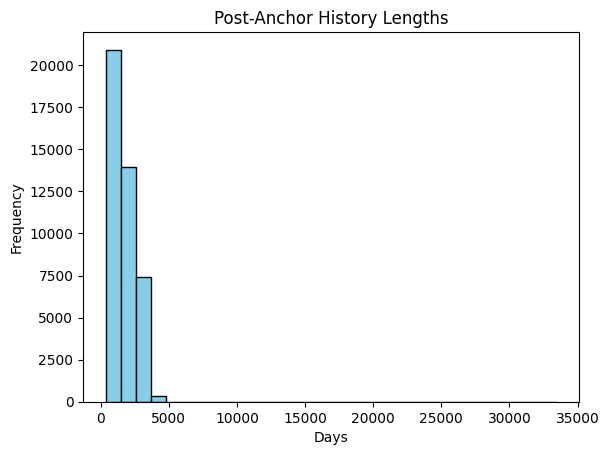

In [23]:
from datetime import datetime
import os
from pathlib import Path
import json
import matplotlib.pyplot as plt

from dotenv import load_dotenv
load_dotenv()

sliced_json_dir = Path(os.environ['SLICED_PATIENT_JSON_DIR'])

# Find earliest and latest anchor dates and the difference between them
earliest = None
latest = None
pop_ids = []
anchor_dates = {}
for p in sliced_json_dir.glob("*.json"):
    pop_ids.append(p.stem)
    with open(p, 'r') as f:
        sliced_json = json.load(f)
        anchor = datetime.strptime(sliced_json['anchor_date'], "%Y-%m-%d")
        if earliest == None:
            earliest = anchor
        else:
            earliest = min(earliest, anchor)
            
        if latest == None:
            latest = anchor
        else:
            latest = max(latest, anchor)
            
        # Record the anchor
        anchor_dates[p.stem] = anchor
difference = (latest - earliest).days
print(f"Earliest Anchor Date: {earliest}")
print(f"Latest Anchor Date: {latest}")
print(f"Difference in days: {difference}\n")

# Now for all patients, find the date of the latest encounter and see how much later it occurs than the anchor date
raw_json_path = Path(os.environ['PATIENT_JSON_DIR'])
post_anchor_history_lengths = []
for id in pop_ids:
    patient_raw_json_path = raw_json_path / f"{id}.json"
    with open(patient_raw_json_path, 'r') as f:
        raw_patient_json = json.load(f)
        latest_encounter_date = None
        for encounter in raw_patient_json['encounters']:
            start = datetime.strptime(encounter['details']['start_visit'], "%Y-%m-%d")
            if latest_encounter_date is None or start > latest_encounter_date:
                latest_encounter_date = start
        # Now find the difference between that and the anchor date
        post_anchor_history_lengths.append((latest_encounter_date - anchor_dates[id]).days)

# Create histogram
plt.hist(post_anchor_history_lengths, bins=30, color='skyblue', edgecolor='black')

# Add labels
plt.title('Post-Anchor History Lengths')
plt.xlabel('Days')
plt.ylabel('Frequency')

plt.show()

In [24]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import sys
sys.path.append(str(Path(os.getcwd()).parent))

from dotenv import load_dotenv
load_dotenv()

from IPython.display import display

from scripts.pipeline.predictions.trd_predictor import TRDPredictor
from scripts.shared.utils import VITAL_COLUMNS
from scripts.shared.feature_display_names import humanize_feature_names

predictor = TRDPredictor(save_time_hist=False)

# Exploratory by-dtype descriptive summary, TRD-stratified. Three tidy tables, one CSV each.
# (Table 1 below is the publication-formatted version with SMDs; this is the fuller describe().)
features = pd.read_parquet(Path(os.environ['FEATURE_DATAFRAME_PATH']))
# Parquet stores nominal fields as object; cast to category so they group correctly (mirrors load_data_set).
obj_cols = features.select_dtypes(include='object').columns
features[obj_cols] = features[obj_cols].astype('category')
features = features.drop(columns=list(VITAL_COLUMNS))
features['trd_label'] = features.index.map(predictor.get_trd_status)

pos = features[features['trd_label'] == 1]
neg = features[features['trd_label'] == 0]

float_cols = features.select_dtypes(include='float64').columns
bool_cols = features.select_dtypes(include='bool').columns
cat_cols = features.select_dtypes(include='category').columns

save_folder = Path("figures")
save_folder.mkdir(parents=True, exist_ok=True)

# --- Numeric: full describe() per group, stacked tidy (feature x group) ---
numeric_blocks = []
for group_name, frame in [('overall', features), ('trd_neg', neg), ('trd_pos', pos)]:
    block = frame[float_cols].describe().T
    block.insert(0, 'group', group_name)
    block.index.name = 'feature'
    numeric_blocks.append(block.reset_index())
numeric_summary = pd.concat(numeric_blocks, ignore_index=True).sort_values(['feature', 'group']).reset_index(drop=True)
numeric_summary.insert(1, 'display', humanize_feature_names(numeric_summary['feature']))

# --- Boolean: True-rate per group + TRD delta, ordered by |delta| ---
boolean_summary = pd.DataFrame({
    'overall_pct': features[bool_cols].mean() * 100,
    'trd_neg_pct': neg[bool_cols].mean() * 100,
    'trd_pos_pct': pos[bool_cols].mean() * 100,
    'overall_n_true': features[bool_cols].sum(),
    'trd_pos_n_true': pos[bool_cols].sum(),
    'trd_neg_n_true': neg[bool_cols].sum(),
})
boolean_summary['delta_pct'] = boolean_summary['trd_pos_pct'] - boolean_summary['trd_neg_pct']
boolean_summary = boolean_summary.round(2).sort_values('delta_pct', key=abs, ascending=False)
boolean_summary.index.name = 'feature'
boolean_summary = boolean_summary.reset_index()
boolean_summary.insert(1, 'display', humanize_feature_names(boolean_summary['feature']))

# --- Categorical: per (feature, level) share per group + TRD delta ---
categorical_rows = []
for col in cat_cols:
    overall_share = features[col].value_counts(normalize=True, dropna=False) * 100
    pos_share = pos[col].value_counts(normalize=True, dropna=False) * 100
    neg_share = neg[col].value_counts(normalize=True, dropna=False) * 100
    for level in overall_share.index:
        is_missing = isinstance(level, float) and np.isnan(level)
        label = 'Missing' if is_missing else str(level)
        display_name = f"{col}: Missing" if is_missing else humanize_feature_names([f"{col}_{level}"])[0]
        categorical_rows.append({
            'feature': col,
            'level': label,
            'display': display_name,
            'overall_pct': round(overall_share.get(level, 0.0), 2),
            'trd_neg_pct': round(neg_share.get(level, 0.0), 2),
            'trd_pos_pct': round(pos_share.get(level, 0.0), 2),
        })
categorical_summary = pd.DataFrame(categorical_rows)
categorical_summary['delta_pct'] = (categorical_summary['trd_pos_pct'] - categorical_summary['trd_neg_pct']).round(2)

numeric_summary.to_csv(save_folder / "numeric_summary.csv", index=False)
boolean_summary.to_csv(save_folder / "boolean_summary.csv", index=False)
categorical_summary.to_csv(save_folder / "categorical_summary.csv", index=False)

print("Numeric summary (describe per group):")
display(numeric_summary)
print("Boolean summary (True-rate, ordered by |TRD delta|):")
display(boolean_summary)
print("Categorical summary (level share per group):")
display(categorical_summary)

Numeric summary (describe per group):


,feature,display,group,count,mean,std,min,25%,50%,75%,max
0,AgeInYears,Age (years),overall,42579.0,54.437821,19.396809,18.0,38.0,55.0,70.0,110.0
1,AgeInYears,Age (years),trd_neg,35124.0,55.085042,19.462916,18.0,39.0,56.0,71.0,109.0
2,AgeInYears,Age (years),trd_pos,7455.0,51.388464,18.785856,18.0,36.0,51.0,66.0,110.0
3,benzo_days_coverage,Anxiolytic days before index,overall,42579.0,23.269804,98.678732,0.0,0.0,0.0,0.0,730.0
4,benzo_days_coverage,Anxiolytic days before index,trd_neg,35124.0,22.603434,97.290509,0.0,0.0,0.0,0.0,730.0
5,benzo_days_coverage,Anxiolytic days before index,trd_pos,7455.0,26.409390,104.922513,0.0,0.0,0.0,0.0,729.0
6,hypnotics_burden,Sleep meds active at index,overall,42579.0,0.041171,0.209728,0.0,0.0,0.0,0.0,3.0
7,hypnotics_burden,Sleep meds active at index,trd_neg,35124.0,0.041055,0.209040,0.0,0.0,0.0,0.0,3.0
8,hypnotics_burden,Sleep meds active at index,trd_pos,7455.0,0.041717,0.212951,0.0,0.0,0.0,0.0,3.0
9,in_patient_days,Inpatient days before index,overall,42579.0,2.460603,12.435258,0.0,0.0,0.0,0.0,756.0


Boolean summary (True-rate, ordered by |TRD delta|):


,feature,display,overall_pct,trd_neg_pct,trd_pos_pct,overall_n_true,trd_pos_n_true,trd_neg_n_true,delta_pct
0,psych_ANXIETY,Anxiety disorder,52.61,50.97,60.35,22401,4499,17902,9.38
1,medical_HYPERLIPIDEMIA,High cholesterol,36.98,38.56,29.54,15747,2202,13545,-9.03
2,psych_INSOMNIA,Insomnia,21.96,20.87,27.11,9350,2021,7329,6.24
3,psych_SUD,Substance use disorder (any),21.76,20.67,26.91,9265,2006,7259,6.24
4,safety_UNCONTROLLED_HTN,Uncontrolled hypertension,36.83,37.91,31.74,15680,2366,13314,-6.17
5,suicide_flag,Suicidality,4.12,3.17,8.60,1753,641,1112,5.43
6,sud_Nicotine,Nicotine use disorder,16.35,15.75,19.20,6963,1431,5532,3.45
7,psych_PTSD,PTSD,3.62,3.11,6.04,1541,450,1091,2.93
8,sud_Alcohol,Alcohol use disorder,4.40,3.91,6.72,1875,501,1374,2.81
9,medical_DIABETES,Diabetes,17.73,18.18,15.59,7548,1162,6386,-2.59


Categorical summary (level share per group):


,feature,level,display,overall_pct,trd_neg_pct,trd_pos_pct,delta_pct
0,Sex,Female,Sex_Female,72.45,72.02,74.47,2.45
1,Sex,Male,Sex: Male,27.54,27.97,25.53,-2.44
2,Sex,Missing,Sex: Missing,0.00,0.00,0.00,0.00
3,PreferredLanguage,English Only,Language: English,98.93,98.86,99.25,0.39
4,PreferredLanguage,Spanish,Language: Spanish,0.78,0.82,0.59,-0.23
5,PreferredLanguage,Missing,PreferredLanguage: Missing,0.10,0.11,0.04,-0.07
6,PreferredLanguage,Asian and Pacific Island,Language: Asian/Pacific Islander,0.09,0.10,0.04,-0.06
7,PreferredLanguage,Other,Language: Other,0.07,0.07,0.05,-0.02
8,PreferredLanguage,Other Indo-European,Language: Other Indo-European,0.04,0.04,0.03,-0.01
9,MaritalStatus,Now Married,Marital status: Married,49.25,50.09,45.27,-4.82


## Table 1: patient characteristics, TRD vs non-TRD (TRIPOD-AI 20b)
Median (IQR) and n (%) per feature with SMDs across strata, saved to `figures/table_one.csv`.

In [25]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import sys
sys.path.append(str(Path(os.getcwd()).parent))

from dotenv import load_dotenv
load_dotenv()

from scripts.pipeline.predictions.trd_predictor import TRDPredictor
from scripts.shared.utils import VITAL_COLUMNS
from scripts.shared.feature_display_names import humanize_feature_names

predictor = TRDPredictor(save_time_hist=False)

# Single parquet load underwrites Table 1, subgroup prevalence/missingness, train/test SMD, and density figures.
cohort = pd.read_parquet(Path(os.environ['FEATURE_DATAFRAME_PATH']))
# Mirror load_data_set exactly: object categoricals -> category, vital columns dropped at load time.
obj_cols = cohort.select_dtypes(include='object').columns
cohort[obj_cols] = cohort[obj_cols].astype('category')
cohort = cohort.drop(columns=list(VITAL_COLUMNS))
cohort['trd_label'] = cohort.index.map(predictor.get_trd_status)

# Age band derived from the float AgeInYears column (left-closed bins).
AGE_BINS = [0, 30, 45, 65, np.inf]
AGE_LABELS = ['18-29', '30-44', '45-64', '65+']
cohort['age_band'] = pd.cut(cohort['AgeInYears'], bins=AGE_BINS, labels=AGE_LABELS, right=False).astype('category')

save_folder = Path("figures")
save_folder.mkdir(parents=True, exist_ok=True)

def smd_continuous(pos_values, neg_values):
    pos_values = pos_values.dropna()
    neg_values = neg_values.dropna()
    pooled_sd = np.sqrt((pos_values.var(ddof=1) + neg_values.var(ddof=1)) / 2)
    if pooled_sd == 0 or np.isnan(pooled_sd):
        return 0.0
    return (pos_values.mean() - neg_values.mean()) / pooled_sd

def smd_binary(p_pos, p_neg):
    pooled_sd = np.sqrt((p_pos * (1 - p_pos) + p_neg * (1 - p_neg)) / 2)
    if pooled_sd == 0:
        return 0.0
    return (p_pos - p_neg) / pooled_sd

def median_iqr(series):
    series = series.dropna()
    return f"{series.median():.1f} ({series.quantile(0.25):.1f}-{series.quantile(0.75):.1f})"

def n_pct(mask):
    return f"{int(mask.sum())} ({mask.mean() * 100:.1f}%)"

def humanize_level(col, level):
    if col == 'age_band':
        return f"Age band: {level}"
    return humanize_feature_names([f"{col}_{level}"])[0]

pos = cohort[cohort['trd_label'] == 1]
neg = cohort[cohort['trd_label'] == 0]
table_one_rows = []

# Continuous features: median (IQR) + continuous SMD
for col in cohort.select_dtypes(include='float64').columns:
    table_one_rows.append({
        'variable': col, 'display': humanize_feature_names([col])[0], 'level': 'median (IQR)',
        'overall': median_iqr(cohort[col]),
        'trd_positive': median_iqr(pos[col]),
        'trd_negative': median_iqr(neg[col]),
        'smd': round(smd_continuous(pos[col], neg[col]), 3)
    })

# Boolean single-flag and multi-label indicators: n (%) True + binary SMD
for col in cohort.select_dtypes(include='bool').columns:
    table_one_rows.append({
        'variable': col, 'display': humanize_feature_names([col])[0], 'level': 'True',
        'overall': n_pct(cohort[col]),
        'trd_positive': n_pct(pos[col]),
        'trd_negative': n_pct(neg[col]),
        'smd': round(smd_binary(pos[col].mean(), neg[col].mean()), 3)
    })

# Categorical (incl. derived age_band): per-level n (%) + per-level binary SMD
for col in cohort.select_dtypes(include='category').columns:
    for level in cohort[col].cat.categories:
        all_ind, pos_ind, neg_ind = cohort[col].eq(level), pos[col].eq(level), neg[col].eq(level)
        table_one_rows.append({
            'variable': col, 'display': humanize_level(col, level), 'level': str(level),
            'overall': n_pct(all_ind),
            'trd_positive': n_pct(pos_ind),
            'trd_negative': n_pct(neg_ind),
            'smd': round(smd_binary(pos_ind.mean(), neg_ind.mean()), 3)
        })
    if cohort[col].isna().any():
        all_ind, pos_ind, neg_ind = cohort[col].isna(), pos[col].isna(), neg[col].isna()
        table_one_rows.append({
            'variable': col, 'display': f"{col}: Missing", 'level': 'Missing',
            'overall': n_pct(all_ind),
            'trd_positive': n_pct(pos_ind),
            'trd_negative': n_pct(neg_ind),
            'smd': round(smd_binary(pos_ind.mean(), neg_ind.mean()), 3)
        })

table_one = pd.DataFrame(table_one_rows)
table_one.to_csv(save_folder / "table_one.csv", index=False)
table_one

,variable,display,level,overall,trd_positive,trd_negative,smd
0,mdd_to_anchor_days,MDD history before index (days),median (IQR),0.0 (0.0-20.0),0.0 (0.0-10.0),0.0 (0.0-22.0),-0.051
1,num_encounters,Encounter count,median (IQR),21.0 (8.0-46.0),17.0 (6.0-40.0),21.0 (8.0-47.0),-0.140
2,pre_anchor_history_days,History length (days),median (IQR),1792.0 (1216.0-2546.0),1629.0 (1141.0-2334.5),1829.5 (1239.0-2587.0),-0.198
3,AgeInYears,Age (years),median (IQR),55.0 (38.0-70.0),51.0 (36.0-66.0),56.0 (39.0-71.0),-0.193
4,benzo_days_coverage,Anxiolytic days before index,median (IQR),0.0 (0.0-0.0),0.0 (0.0-0.0),0.0 (0.0-0.0),0.038
...,...,...,...,...,...,...,...
93,mdd_severity,MDD severity: Unspecified,Unspecified,28951 (68.0%),4803 (64.4%),24148 (68.8%),-0.092
94,age_band,Age band: 18-29,18-29,5513 (12.9%),1135 (15.2%),4378 (12.5%),0.080
95,age_band,Age band: 30-44,30-44,9025 (21.2%),1836 (24.6%),7189 (20.5%),0.100
96,age_band,Age band: 45-64,45-64,13268 (31.2%),2445 (32.8%),10823 (30.8%),0.043


## TRD rate by demographic group (TRIPOD-AI 3c & 14)
By Sex, Race, language, age band, and SDOH; n < 20 cells flagged. Saved to `figures/subgroup_trd_prevalence.csv`.

In [26]:
from scripts.shared.feature_display_names import humanize_feature_names

sdoh_cols = [c for c in cohort.columns if c.startswith('sdoh_')]
subgroup_vars = ['Sex', 'Race_Ethnicity', 'PreferredLanguage', 'age_band'] + sdoh_cols

prevalence_rows = []
for var in subgroup_vars:
    grouped = cohort.groupby(var, observed=True, dropna=False)['trd_label']
    for level, group in grouped:
        n = len(group)
        n_trd_pos = int(group.sum())
        prevalence_rows.append({
            'subgroup': var,
            'subgroup_display': humanize_feature_names([var])[0],
            'level': str(level),
            'n': n,
            'n_trd_pos': n_trd_pos,
            'trd_rate_pct': round(n_trd_pos / n * 100, 1) if n else np.nan,
            'small_cell_lt20': n < 20
        })

subgroup_prevalence = pd.DataFrame(prevalence_rows)
subgroup_prevalence.to_csv(save_folder / "subgroup_trd_prevalence.csv", index=False)
print(f"Flagged {int(subgroup_prevalence['small_cell_lt20'].sum())} small (<20) cells out of {len(subgroup_prevalence)}.")
subgroup_prevalence

Flagged 3 small (<20) cells out of 39.


,subgroup,subgroup_display,level,n,n_trd_pos,trd_rate_pct,small_cell_lt20
0,Sex,Sex,Female,30850,5552,18.0,False
1,Sex,Sex,Male,11728,1903,16.2,False
2,Sex,Sex,nan,1,0,0.0,True
3,Race_Ethnicity,Race_Ethnicity,American Indian or Alaska Native,2033,394,19.4,False
4,Race_Ethnicity,Race_Ethnicity,Asian,301,49,16.3,False
5,Race_Ethnicity,Race_Ethnicity,Black or African American,2368,401,16.9,False
6,Race_Ethnicity,Race_Ethnicity,Hispanic or Latino,1772,288,16.3,False
7,Race_Ethnicity,Race_Ethnicity,Multi-Race,1701,333,19.6,False
8,Race_Ethnicity,Race_Ethnicity,Native Hawaiian or Other Pacific Islander,28,2,7.1,False
9,Race_Ethnicity,Race_Ethnicity,White or Caucasian,34079,5942,17.4,False


## Is missingness worse for some groups? (TRIPOD-AI 7)
Per-subgroup missing rate for any column still carrying NaNs. Saved to `figures/subgroup_missingness.csv`.

In [27]:
from scripts.shared.feature_display_names import humanize_feature_names

strata = ['Sex', 'Race_Ethnicity', 'PreferredLanguage', 'age_band']
audit_cols = [c for c in cohort.columns if c not in (['trd_label', 'age_band'] + strata) and cohort[c].isna().any()]

if not audit_cols:
    print("No non-vital columns carry missingness post-load. The remaining feature block is clean across subgroups.")
    subgroup_missingness = pd.DataFrame(columns=['column', 'column_display', 'stratum', 'level', 'n', 'missing_pct'])
else:
    print(f"Columns with residual missingness: {audit_cols}")
    missingness_rows = []
    for col in audit_cols:
        is_missing = cohort[col].isna()
        for stratum in strata:
            for level, group in cohort.groupby(stratum, observed=True, dropna=False):
                sub = is_missing.loc[group.index]
                missingness_rows.append({
                    'column': col,
                    'column_display': humanize_feature_names([col])[0],
                    'stratum': stratum,
                    'level': str(level),
                    'n': len(sub),
                    'missing_pct': round(sub.mean() * 100, 1)
                })
    subgroup_missingness = pd.DataFrame(missingness_rows)

subgroup_missingness.to_csv(save_folder / "subgroup_missingness.csv", index=False)
subgroup_missingness

Columns with residual missingness: ['MaritalStatus', 'Religion', 'SmokingStatus']


,column,column_display,stratum,level,n,missing_pct
0,MaritalStatus,MaritalStatus,Sex,Female,30850,0.4
1,MaritalStatus,MaritalStatus,Sex,Male,11728,0.4
2,MaritalStatus,MaritalStatus,Sex,nan,1,0.0
3,MaritalStatus,MaritalStatus,Race_Ethnicity,American Indian or Alaska Native,2033,0.1
4,MaritalStatus,MaritalStatus,Race_Ethnicity,Asian,301,0.7
...,...,...,...,...,...,...
58,SmokingStatus,SmokingStatus,PreferredLanguage,nan,41,7.3
59,SmokingStatus,SmokingStatus,age_band,18-29,5513,1.0
60,SmokingStatus,SmokingStatus,age_band,30-44,9025,0.8
61,SmokingStatus,SmokingStatus,age_band,45-64,13268,1.2


## Do train and test patients look alike? (TRIPOD-AI 20c & 21)
Split sizes, TRD counts, and per-predictor SMDs across train vs test. Saved to `figures/train_test_smd.csv`.

In [28]:
from scripts.pipeline.predictions.create_train_test_split import create_train_test_split
from scripts.shared.feature_display_names import humanize_feature_names

train_ids, test_ids = create_train_test_split()
cohort['split'] = np.where(cohort.index.isin(test_ids), 'test', 'train')

# 21 - split sizes and TRD-positive counts
split_summary = cohort.groupby('split')['trd_label'].agg(n='size', n_trd_pos='sum')
split_summary['trd_rate_pct'] = (split_summary['n_trd_pos'] / split_summary['n'] * 100).round(1)
print(split_summary)

# 20c - SMD across train vs test for every predictor column
train = cohort[cohort['split'] == 'train']
test = cohort[cohort['split'] == 'test']
exclude = {'trd_label', 'age_band', 'split'}

smd_rows = []
for col in cohort.select_dtypes(include='float64').columns:
    if col in exclude:
        continue
    smd_rows.append({'variable': col, 'display': humanize_feature_names([col])[0], 'level': 'mean', 'smd': round(smd_continuous(train[col], test[col]), 3)})
for col in cohort.select_dtypes(include='bool').columns:
    smd_rows.append({'variable': col, 'display': humanize_feature_names([col])[0], 'level': 'True', 'smd': round(smd_binary(train[col].mean(), test[col].mean()), 3)})
for col in cohort.select_dtypes(include='category').columns:
    if col in exclude:
        continue
    for level in cohort[col].cat.categories:
        smd_rows.append({'variable': col, 'display': humanize_feature_names([f"{col}_{level}"])[0], 'level': str(level), 'smd': round(smd_binary(train[col].eq(level).mean(), test[col].eq(level).mean()), 3)})

train_test_smd = pd.DataFrame(smd_rows).sort_values('smd', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
train_test_smd.to_csv(save_folder / "train_test_smd.csv", index=False)
train_test_smd

Found 42579 total patients.
Split into train set of size 34063 and test set of size 8516.
Train set TRD count: 5964
Test set TRD count: 1491
           n  n_trd_pos  trd_rate_pct
split                                
test    8516       1491          17.5
train  34063       5964          17.5


,variable,display,level,smd
0,sdoh_Occupational Exposure,Occupational hazard exposure,True,0.036
1,mdd_recurrence,MDD recurrence: Single episode,Single Episode,-0.025
2,Religion,Religion: Other/Unknown,Other/Unknown,-0.024
3,MaritalStatus,Marital status: Never married,Never Married,0.024
4,MaritalStatus,Marital status: Widowed,Widowed,-0.024
...,...,...,...,...
83,sdoh_Primary Support Group/Family,Family/support group issue,True,0.000
84,safety_UNCONTROLLED_HTN,Uncontrolled hypertension,True,0.000
85,safety_EPILEPSY,Seizure disorder,True,0.000
86,sud_Other Substance,Other substance use disorder,True,0.000


## Enough TRD cases per feature? (TRIPOD-AI 10)
Training TRD-positives divided by feature count, checked against the >= 10 rule.

In [29]:
import joblib
from scripts.pipeline.predictions.classical_ml import model_cache_path
from scripts.shared.utils import VectorSource

# TRD-positive numerator is shared across sources (same split, same labels).
n_trd_pos_train = int(cohort[cohort['split'] == 'train']['trd_label'].sum())
print(f"Training TRD-positive events: {n_trd_pos_train}\n")

for source in VectorSource:
    cache_path = model_cache_path('logistic_regression', source)
    if not cache_path.exists():
        print(f"[{source.name}] No cached searcher at {cache_path}. "
              f"Run the baseline {source.name} classical_ml.py pass first.\n")
        continue
    preprocessor = joblib.load(cache_path).best_estimator_.named_steps['preprocess']
    n_features = len(preprocessor.get_feature_names_out())
    epv = n_trd_pos_train / n_features
    print(f"[{source.name}] Post-ColumnTransformer feature count: {n_features}")
    print(f"[{source.name}] Events-per-variable: {epv:.3f}")
    print(f"[{source.name}] Meets traditional EPV >= 10 threshold: {epv >= 10}\n")

Training TRD-positive events: 5964

[EMBEDDED] No cached searcher at /media/studies/ehr_study/analysis/mferguson/artifacts/Qwen-Qwen3-Embedding-8B/google_medgemma-27b-text-it/trained_models/logistic_regression_EMBEDDED.joblib. Run the baseline EMBEDDED classical_ml.py pass first.

[FEATURE] No cached searcher at /media/studies/ehr_study/analysis/mferguson/artifacts/Qwen-Qwen3-Embedding-8B/google_medgemma-27b-text-it/trained_models/logistic_regression_FEATURE.joblib. Run the baseline FEATURE classical_ml.py pass first.



## Distribution plots for three continuous predictors (TRIPOD-AI supporting)
TRD vs non-TRD densities plus a correlation table. Saved to `figures/density_*.png` and `figures/density_correlation.csv`.

          trd_rate      n
same_day                 
False     0.159000  14673
True      0.183545  27906


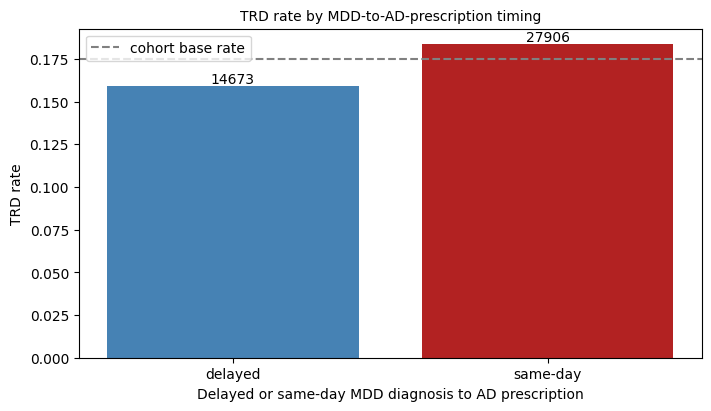

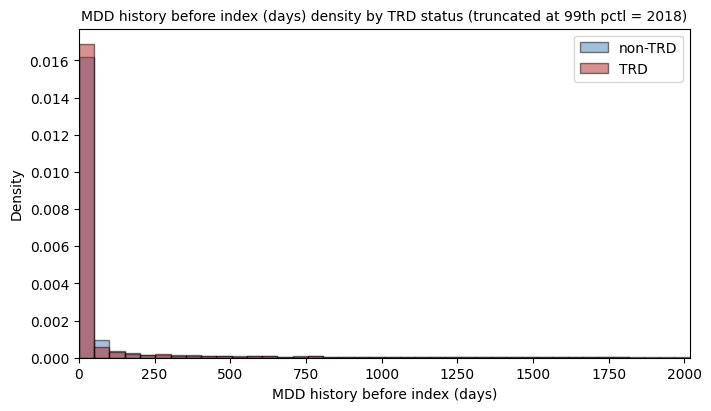

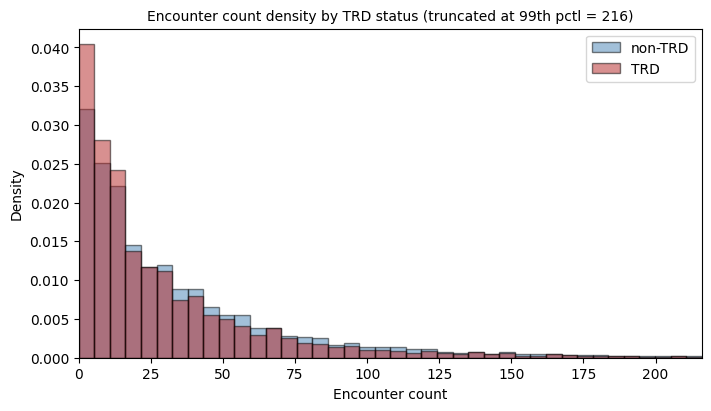

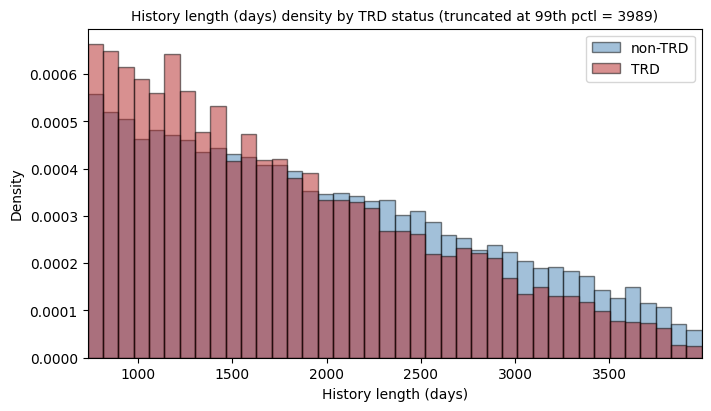

,feature,display,pearson_r,pearson_p,spearman_r,spearman_p
0,mdd_to_anchor_days,MDD history before index (days),-0.0188,0.000107,-0.0289,0.0
1,num_encounters,Encounter count,-0.0499,0.000000,-0.0637,0.0
2,pre_anchor_history_days,History length (days),-0.0734,0.000000,-0.0730,0.0


In [30]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

from scripts.shared.feature_display_names import humanize_feature_names

density_cols = ['mdd_to_anchor_days', 'num_encounters', 'pre_anchor_history_days']
density_labels = dict(zip(density_cols, humanize_feature_names(density_cols)))
pos = cohort[cohort['trd_label'] == 1]
neg = cohort[cohort['trd_label'] == 0]

# Per-column right bound: histograms are truncated at this percentile of the pooled cohort so the
# bins pack into the low-value region where the TRD/non-TRD difference lives. Presentation only --
# the correlation table below still uses the full, untruncated data.
RIGHT_BOUND_PCT = 0.99
SAME_DAY_THRESHOLD = 1 # MDD documented at the index visit

# All Figure-1 panels share one figure size and are saved WITHOUT bbox_inches='tight', so each panel
# is exactly FIGSIZE*dpi pixels and they tile into a uniform 2x2 in the manuscript. constrained_layout
# plus a smaller title font keeps the long titles inside the fixed canvas; bbox_inches='tight' would
# re-expand the canvas per-title and reintroduce the ragged panel widths we are avoiding.
FIGSIZE = (7, 4)
TITLE_FONTSIZE = 10

for col in density_cols:
    right_bound = cohort[col].quantile(RIGHT_BOUND_PCT)
    left_bound = cohort[col].min()
    neg_clipped = neg[col].dropna()
    pos_clipped = pos[col].dropna()
    neg_clipped = neg_clipped[neg_clipped <= right_bound]
    pos_clipped = pos_clipped[pos_clipped <= right_bound]

    if col == "mdd_to_anchor_days":
        cohort_copy = cohort.copy()
        cohort_copy['same_day'] = cohort['mdd_to_anchor_days'] <= SAME_DAY_THRESHOLD
        group_summmary = cohort_copy.groupby(by='same_day').agg(trd_rate=('trd_label','mean'), n=('trd_label','size'))
        print(group_summmary)

        labels = ["delayed", "same-day"]
        fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)
        bars = ax.bar(labels, group_summmary['trd_rate'], color=['steelblue', 'firebrick'])
        mean_trd = cohort['trd_label'].mean()
        ax.axhline(mean_trd, linestyle='--', color='gray', label="cohort base rate")
        ax.bar_label(bars, group_summmary['n'])
        ax.set_ylabel("TRD rate")
        ax.set_xlabel("Delayed or same-day MDD diagnosis to AD prescription")
        ax.set_title("TRD rate by MDD-to-AD-prescription timing", fontsize=TITLE_FONTSIZE)
        ax.legend()
        fig.savefig(save_folder / f"trd_rate_by_delayed_{col}.png", dpi=150)

    label = density_labels[col]
    fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)
    ax.hist(neg_clipped, bins=40, range=(left_bound, right_bound), density=True, alpha=0.5, label='non-TRD', color='steelblue', edgecolor='black')
    ax.hist(pos_clipped, bins=40, range=(left_bound, right_bound), density=True, alpha=0.5, label='TRD', color='firebrick', edgecolor='black')
    ax.set_xlim(left_bound, right_bound)
    ax.set_title(f"{label} density by TRD status (truncated at {int(RIGHT_BOUND_PCT * 100)}th pctl = {right_bound:.0f})", fontsize=TITLE_FONTSIZE)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend()
    fig.savefig(save_folder / f"density_{col}.png", dpi=150)
    plt.show()

corr_rows = []
for col in density_cols:
    valid = cohort[[col, 'trd_label']].dropna()
    pearson_r, pearson_p = pearsonr(valid[col], valid['trd_label'])
    spearman_r, spearman_p = spearmanr(valid[col], valid['trd_label'])
    corr_rows.append({
        'feature': col,
        'display': density_labels[col],
        'pearson_r': round(pearson_r, 4),
        'pearson_p': round(pearson_p, 6),
        'spearman_r': round(spearman_r, 4),
        'spearman_p': round(spearman_p, 6)
    })

density_correlation = pd.DataFrame(corr_rows)
density_correlation.to_csv(save_folder / "density_correlation.csv", index=False)
density_correlation

### Notice of a bimodal cosine similarity distribution in bge-small-en-v1.5

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sqlite3
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

from dotenv import load_dotenv
load_dotenv()

CORRECT_EMBEDDER_MODEL = 'bge-small-en-v1.5'
expected_shape = 384
save_folder = Path("figures")

if os.environ['EMBEDDER_MODEL_NAME'] != CORRECT_EMBEDDER_MODEL:
    raise AssertionError(f"Incorrect embedding model specified in .env: {os.environ['EMBEDDER_MODEL_NAME']}")

emb_db_path = Path(os.environ['EMBEDDINGS_DIR']) / "embeddings.db"
connection = sqlite3.connect(emb_db_path)
cursor = connection.cursor()
cursor.execute(
    "SELECT patient_id, embedding, text FROM embeddings"
)
rows = cursor.fetchall()
embeddings = np.vstack([np.frombuffer(r[1], dtype=np.float32) for r in rows], dtype=np.float32)
assert embeddings.shape[1] == expected_shape, f"Expected vectors of size {expected_shape} but received size {embeddings.shape[1]}"
ids, texts = [r[0] for r in rows], [r[2].lower() for r in rows]
normalized = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
sims = normalized @ normalized.T
row_indices, col_indices = np.triu_indices(len(rows), k=1) # k=1 prevents self-pairing with diagonal
pair_sims = sims[(row_indices, col_indices)]

# Use K Means with two clusters
clusterer = KMeans(n_clusters=2, random_state=int(os.environ['SEED']), n_init=10)
cluster_labels = clusterer.fit_predict(normalized) # Fits via Euclidean distance, but since vectors are normalized that's the same as cosine similarity
print(f"Group sizes: {np.bincount(cluster_labels)}")
# For each of the two clusters, we want the probabilities of all words showing up given a narrative is in that cluster
vectorizer = CountVectorizer(binary=True)
presence_matrix = vectorizer.fit_transform(texts) # Shape n_narratives x vocab_size
vocab = vectorizer.get_feature_names_out() # Shape vocab_size
prob0, prob1 = np.asarray(presence_matrix[cluster_labels==0].mean(axis=0)).ravel(),\
    np.asarray(presence_matrix[cluster_labels==1].mean(axis=0)).ravel() # Both of shape vocab_size
# What words have a significantly higher probability of being in one cluster than another?
diffs = np.abs(prob0 - prob1)
top_diff_indices = np.argsort(diffs)[::-1][:20].tolist()
df = pd.DataFrame([
    {
        "vocab": vocab[i],
        "prob_first_cluster": prob0[i],
        "prob_second_cluster": prob1[i],
        "diff": diffs[i]
    }
    for i in top_diff_indices
])
print(df.head())

# Verify that the bimodal distribution coincides with the difference of a buzzword's presence
buzz_word = vocab[top_diff_indices[0]]
print(f"Buzz Word: {buzz_word}")
buzz_word_mask = np.array([buzz_word in t for t in texts])
first_buzz_word = buzz_word_mask[row_indices]
second_buzz_word = buzz_word_mask[col_indices]
differ = pair_sims[first_buzz_word ^ second_buzz_word]
both = pair_sims[first_buzz_word & second_buzz_word]
neither = pair_sims[(~first_buzz_word) & (~second_buzz_word)]

print(f"Mean similarity buzz/no-buzz {differ.mean()}")
print(f"Mean similarity both buzz {both.mean()}")
print(f"Mean similarity neither buzz {neither.mean()}")
# Difference in similarities when they differ or do not differ with having the buzz word
print(f"Cross comparison: {np.concatenate((both, neither)).mean() - differ.mean()}")

fig, ax = plt.subplots(figsize=(10,6))
range_t = (pair_sims.min(), pair_sims.max())
bins = 100
ax.hist(pair_sims, color='gray', alpha=0.3, label="all pairs", range=range_t, bins=bins)
ax.hist(differ, color='firebrick', alpha=0.5, label="differing pairs", range=range_t, bins=bins)
ax.hist(np.concatenate((both, neither)), color='steelblue', alpha=0.5, label="within (same)", range=range_t, bins=bins)
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Frequency")
ax.set_title("bge-small bimodality decomposed by MDD recurrence")
ax.legend()
fig.savefig(save_folder / "bge_small_recurrence_bimodality.png", dpi=150, bbox_inches="tight")
plt.show()

connection.close()